# Bank Account Fraud Dataset Suite (NeurIPS 2022)

출처 - kaggle<br>
https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022?select=Base.csv

## 은행 사기계좌 판별
1. classification model
2. imbalanced data
3. 

In [12]:
import pandas as pd
import numpy as np

import missingno

import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
raw = pd.read_csv('data/Base.csv')
raw.head(5)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [4]:
raw.fraud_bool.value_counts()

fraud_bool
0    988971
1     11029
Name: count, dtype: int64

In [5]:
raw.phone_home_valid.value_counts()

phone_home_valid
0    582923
1    417077
Name: count, dtype: int64

In [6]:
df = raw.copy()

## missing value 

1. no na/null values in dataset

2. some feature has missing value 
    - prev_address_months_count -> -1 <br>
    - current_address_months_count -> -1 <br>
    - intended_balcon_amount -> negative value <br>
    - bank_months_count -> -1 <br>
    - session_length_in_minutes -> -1 <br>
    - device_distinct_emails -> -1 <br>


-> negative value is missing value in these feature

-> missing value to np.nan

## 결측치 수
- prev_address_months_count  / 712920 <br>
-> drop
- current_address_months_count / 4254 <br>
-> na drop
- intended_balcon_amount      / 742523 <br>
-> drop
- bank_months_count           / 253635 <br>
-> imputaion
- session_length_in_minutes   / 2015 <br>
-> na drop
- device_distinct_emails_8w   / 359 <br>
-> na drop

## 결측치 처리 방법 - imputation
https://data-newbie.tistory.com/257

In [7]:
# function to_nan
# negative value to np.nan

def to_nan(feature_list):
    for feature in feature_list:
        df[feature] = df[feature].apply(lambda x: x if x >= 0 else np.nan)

In [8]:
missing_features = ['prev_address_months_count', 'current_address_months_count', 'intended_balcon_amount', 'bank_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w' ]
to_nan(missing_features)

In [9]:
df[missing_features].isna().sum()


prev_address_months_count       712920
current_address_months_count      4254
intended_balcon_amount          742523
bank_months_count               253635
session_length_in_minutes         2015
device_distinct_emails_8w          359
dtype: int64

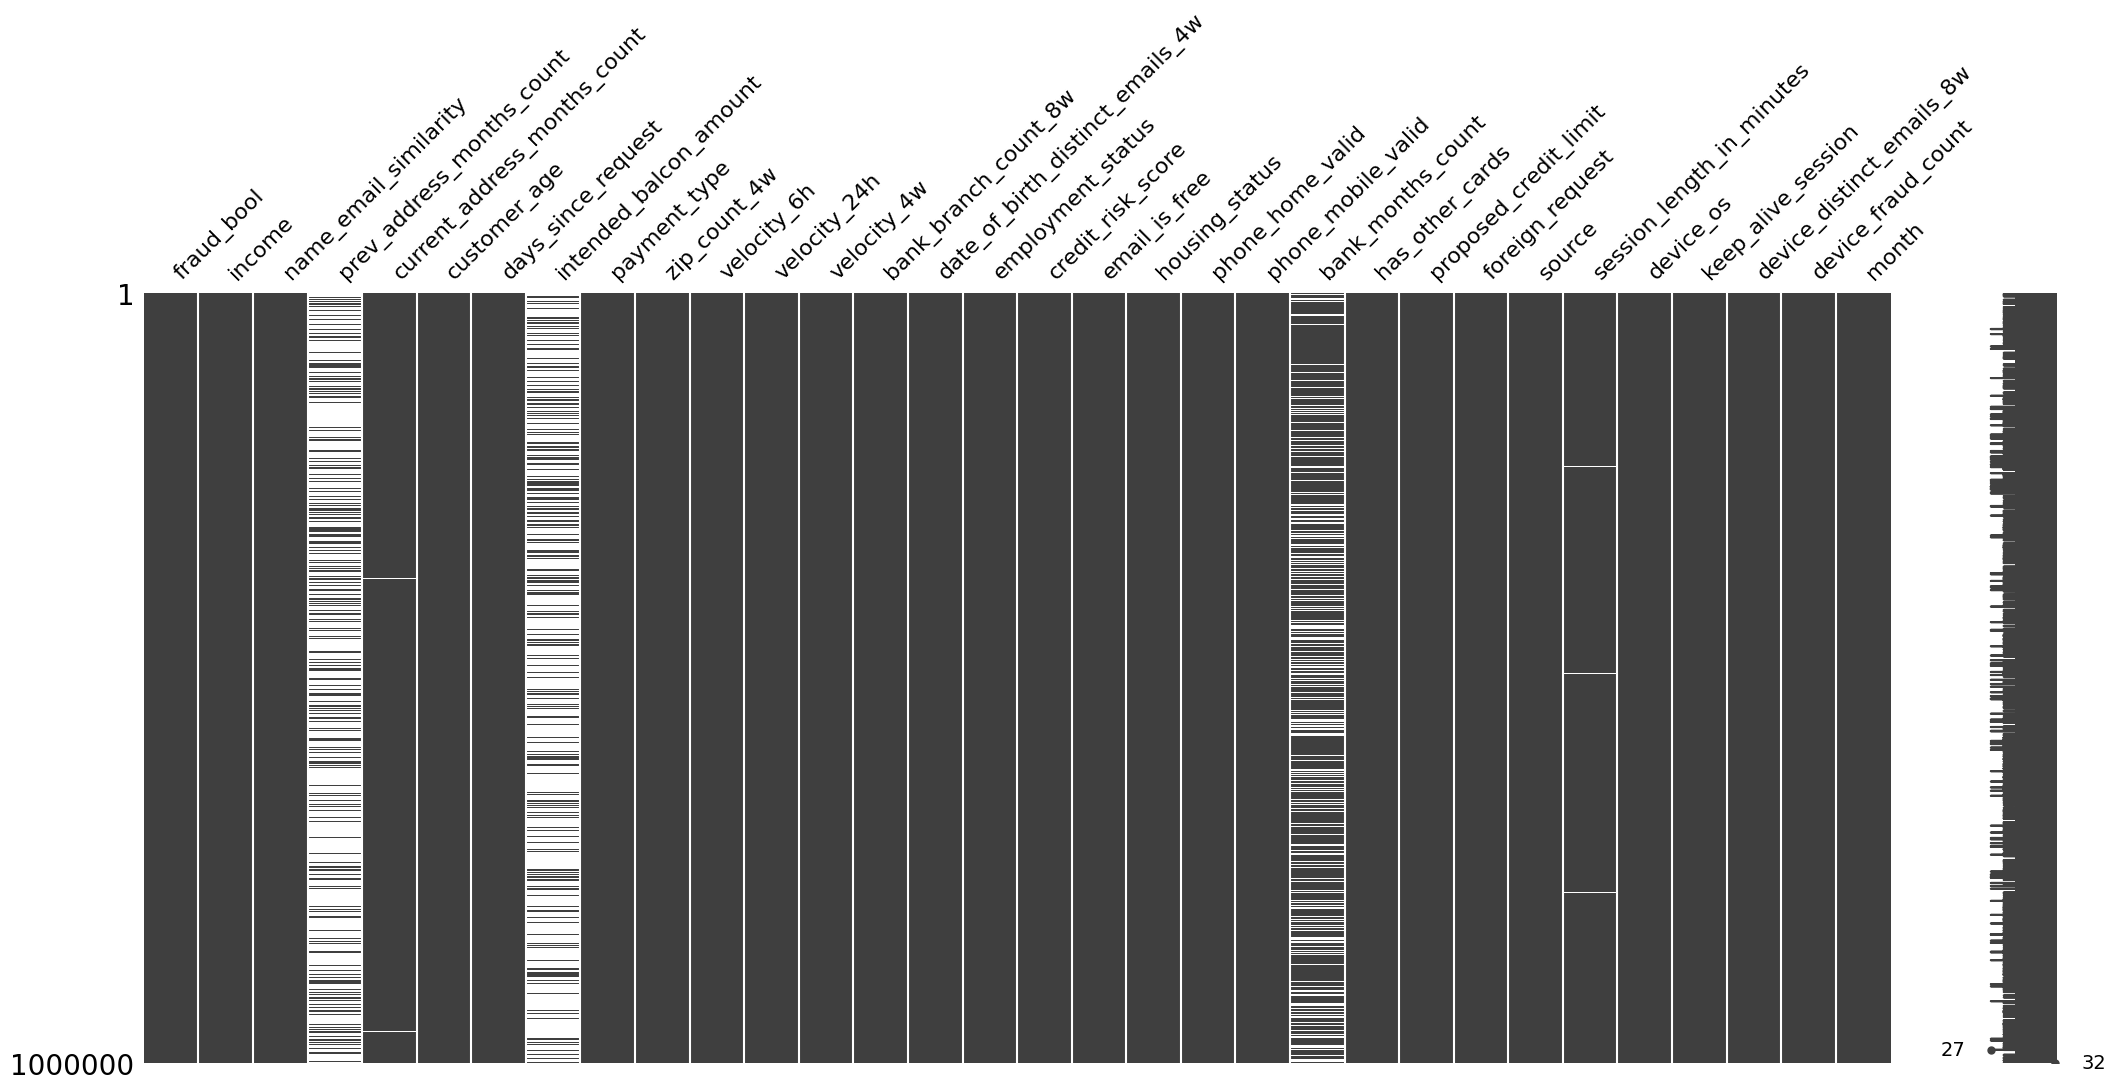

In [13]:
missingno.matrix(df)
plt.show()

#### missing value1 - prev_address_months_count
이전 거주지에서 거주한 기간

nan ->  712920

count    287080.000000
mean         60.719967
std          63.578187
min           5.000000
25%          25.000000
50%          34.000000
75%          72.000000
max         383.000000
Name: prev_address_months_count, dtype: float64

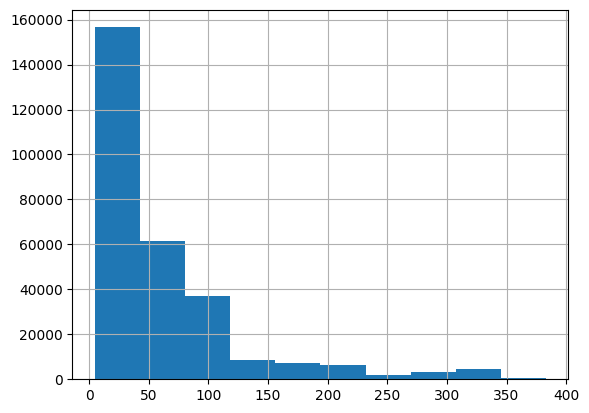

In [10]:
df['prev_address_months_count'].hist()

df['prev_address_months_count'].describe()
# 특정 구간에 몰려있는 경향성을 보임
# 최빈값으로 nan 대체

In [44]:
df['prev_address_months_count'] = df['prev_address_months_count'].fillna(df['prev_address_months_count'].mode()[0])
df['prev_address_months_count'].isna().sum()

0

#### missing value2 - current_address_months_count
현재 거주지에서 거주한 기간

nan -> 4254

count    995746.000000
mean         86.962058
std          88.409289
min           0.000000
25%          20.000000
50%          53.000000
75%         130.000000
max         428.000000
Name: current_address_months_count, dtype: float64

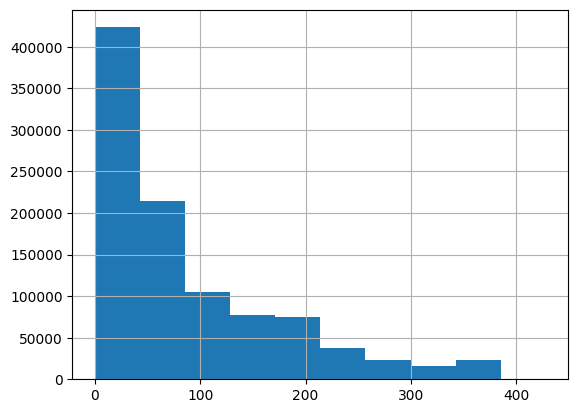

In [48]:
df['current_address_months_count'].hist()
df['current_address_months_count'].describe()

In [49]:
### 100만건 중 4254건이 nan
# 결측치를 포함한 값은 제거

df = df.dropna(subset=['prev_address_months_count'])

In [55]:
df['prev_address_months_count'].isna().sum()

0

#### missing value3 - intended_balcon_amount 
계좌 개설시 입금 금액

count    257477.000000
mean         36.582496
std          23.236885
min           0.000054
25%          20.403236
50%          32.433701
75%          49.586253
max         112.956928
Name: intended_balcon_amount, dtype: float64

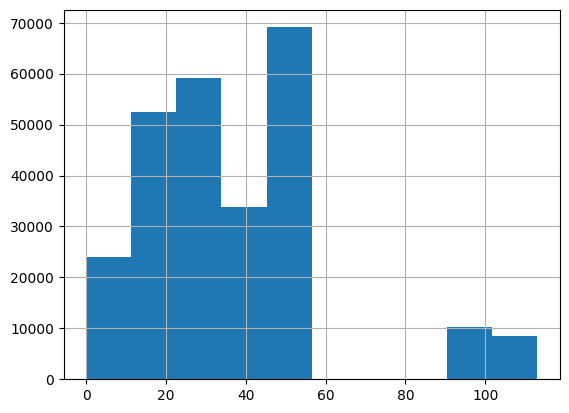

In [50]:
df['intended_balcon_amount'].hist()
df['intended_balcon_amount'].describe()

In [56]:
df['intended_balcon_amount'] = df['intended_balcon_amount'].interpolate()

count    1000000.000000
mean          36.595900
std           19.588294
min            0.000054
25%           23.176248
50%           33.616758
75%           46.971262
max          112.956928
Name: intended_balcon_amount, dtype: float64

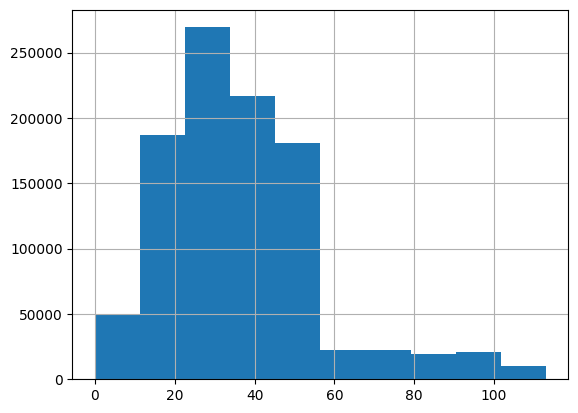

In [57]:
df['intended_balcon_amount'].hist()
df['intended_balcon_amount'].describe()

#### missing value4 - bank_months_count
이전 계좌를 보유한 기간

nan -> 253635건

#### missing value5 - session_length_in_minutes
웹사이트 접속시간

nan -> 2015

In [58]:
df = df.dropna(subset=['session_length_in_minutes'])

#### missing value6 - device_distinct_emails_8w
지난 8주 동안 한 기기에서 사용된 이메일의 수

nan -> 359

In [59]:
df = df.dropna(subset=['device_distinct_emails_8w'])

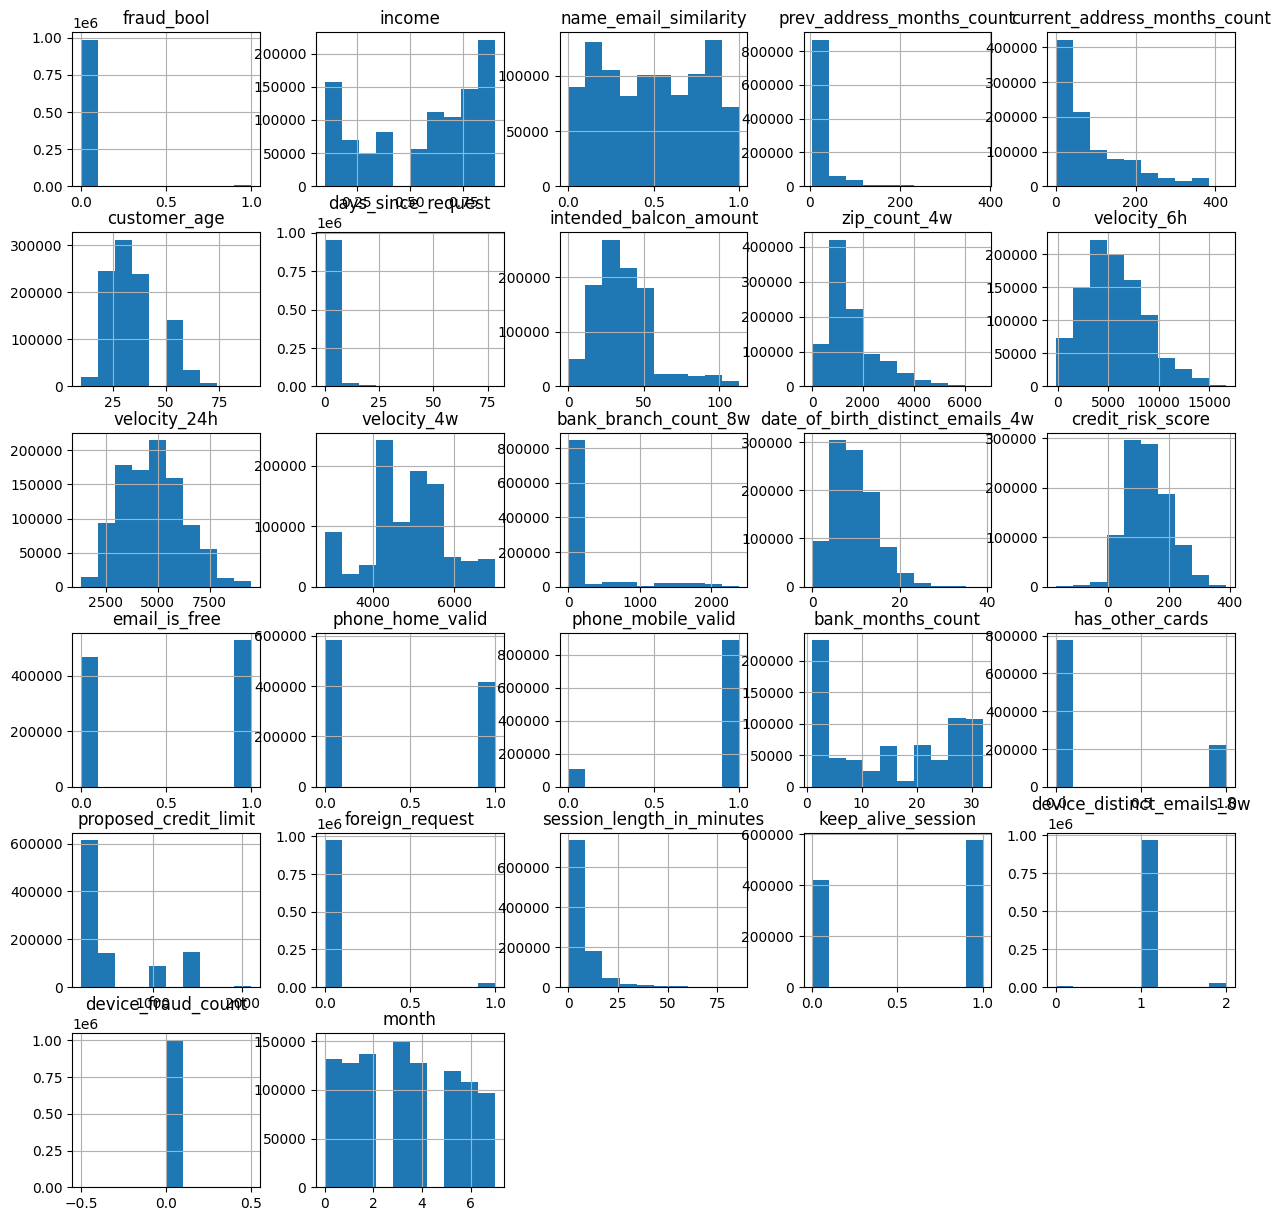

In [60]:
plt.rc('axes', labelsize=14, titlesize=12)
plt.rc('legend', fontsize=14)


df.hist(figsize=(15, 15))
plt.show()

In [61]:
df.columns.nunique()

32

In [62]:
### fraud

df.fraud_bool.value_counts()

# label로 활용될 변수
# 사기 X -> 988971
# 사기 O -> 11029

# imbalanced data
# 100만건 중 11029건의 데이터만 사기 계좌
### 분석에 시작하기 전에 sampling을 다시 해줘야한다.

fraud_bool
0    986848
1     11009
Name: count, dtype: int64

income
0.1    156950
0.2     69152
0.3     50711
0.4     81164
0.5     55725
0.6    111756
0.7    104922
0.8    146392
0.9    221085
Name: count, dtype: int64

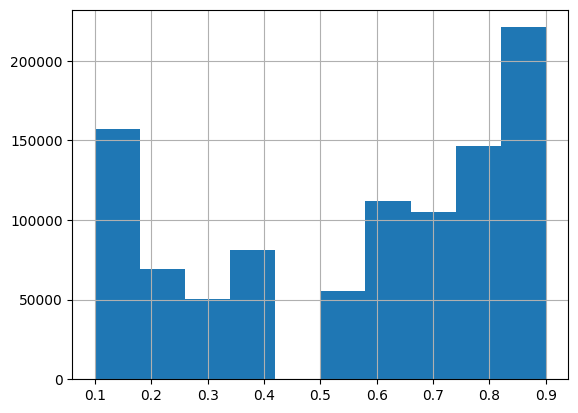

In [63]:
### income - Annual income of the applicant (10분위 형태)
# convex한 형태를 나타냄 -> need to scaling

df.income.hist()
df.income.value_counts().sort_index()

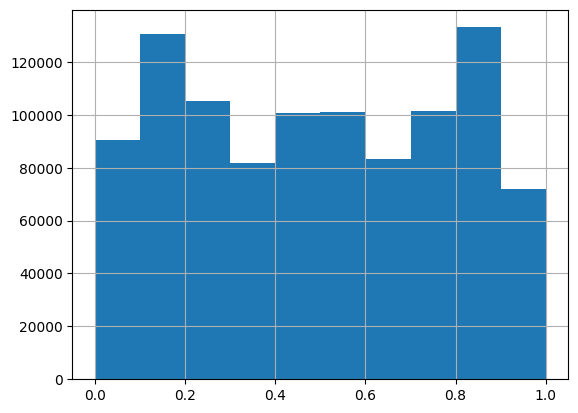

In [14]:
df.name_email_similarity.hist()
plt.show()
# 그대로 사용

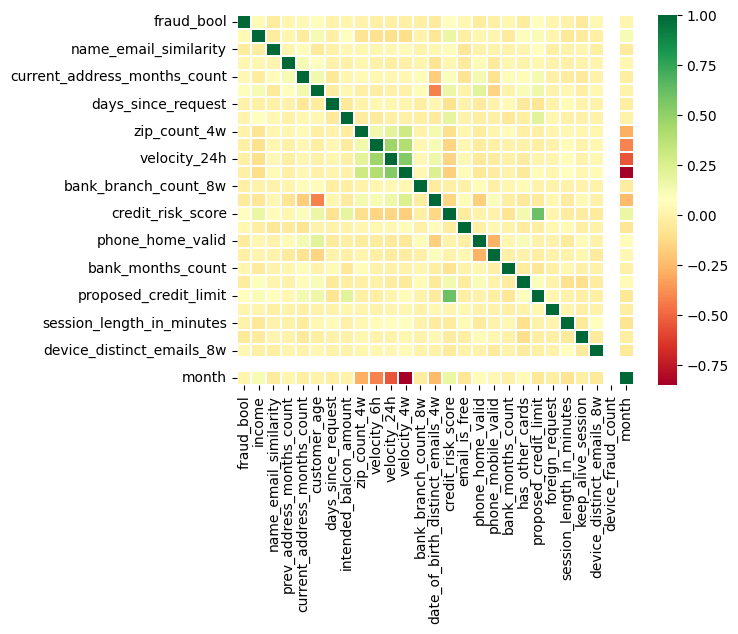

In [15]:
sns.heatmap(df.corr(numeric_only=True), cmap='RdYlGn',linewidths=0.2)
plt.show()

### One-hot encoding

유형 변수들을 처리하는 방법

유형변수
- payment_type
- employment_status
- housing_status
- device_os

In [64]:
df['payment_type'].value_counts()

payment_type
AB    370061
AA    258074
AC    250765
AD    118668
AE       289
Name: count, dtype: int64

In [65]:
df['employment_status'].value_counts()

employment_status
CA    728821
CB    137942
CF     43982
CC     37603
CD     26385
CE     22673
CG       451
Name: count, dtype: int64

In [66]:
df['housing_status'].value_counts()

housing_status
BC    371247
BB    260310
BA    169377
BE    168884
BD     26135
BF      1652
BG       252
Name: count, dtype: int64

In [67]:
df['device_os'].value_counts()

device_os
other        340908
linux        332575
windows      263342
macintosh     53805
x11            7227
Name: count, dtype: int64

In [ ]:
df = pd.get_dummies(df, columns=['payment_type'], dtype='int')
df

In [73]:
df_numeric = df.select_dtypes(exclude=['object'])
df_object = df.select_dtypes(include=['object'])

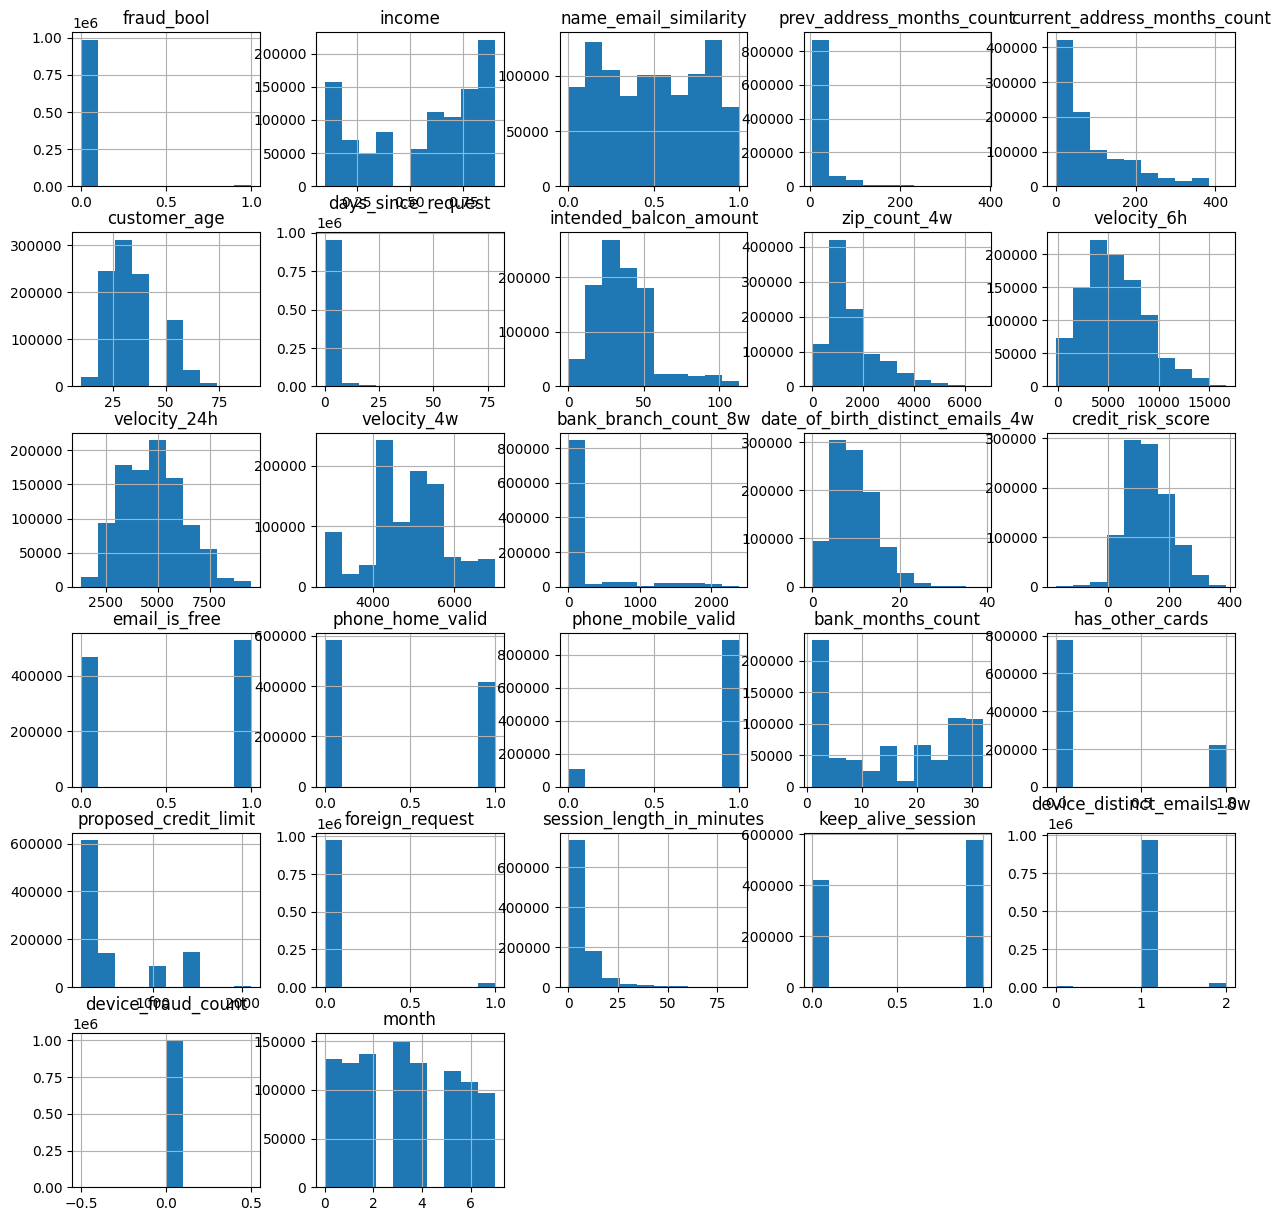

In [75]:
plt.rc('axes', labelsize=14, titlesize=12)
plt.rc('legend', fontsize=14)
df_numeric.hist(figsize=(15,15))

plt.show()

In [69]:
### delete OUTLIER

### SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
X_resampled, y_resampled = sm.fit_resample(train_X, train_y)